# Corpus EDA — Information Loss in Video Transcripts

**Research question.** Can a transcript-only Transformer identify low-contribution segments such that removing them causes minimal loss of factual/semantic content, and does this performance vary across length and genre?

**Hypotheses this EDA touches:**
- **H1** — longer videos contain proportionally more removable content. We characterize length distributions and look at length × redundancy proxies.
- **H3** — performance varies by genre. We compare per-genre filler density, lexical diversity, and repetition.
- **H4** — transcript-only model struggles with visual / pedagogical importance. We measure proxies (speech rate, visual-reference markers) that hint at how much content lives off-transcript.
- **H2** is not testable in EDA — it requires the model. But we set up the segment-level features that will feed weak labeling.

**Outputs:**
- Visualizations of corpus shape and per-genre features.
- `data/processed/corpus_summary.csv` — per-video summary (no raw transcript) used in later hypothesis tests.

**Caveat:** every per-video metric in this notebook is a **proxy**, not ground truth for "information loss" or "importance." Their job is to characterize the corpus and inform the weak labeling functions — the real evaluation happens later on the gold subset.

In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load corpus

One row per video. The full transcript stays in memory only while we compute features — it is dropped before we save the summary frame.

In [2]:
def load_corpus(raw_dir: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(raw_dir.rglob("*.json")):
        try:
            doc = json.loads(path.read_text(encoding="utf-8"))
        except Exception as e:
            print(f"  skip {path.name}: {e}")
            continue
        rows.append({
            "video_id": doc["video_id"],
            "genre": doc["genre"],
            "channel": doc.get("channel"),
            "title": doc.get("title"),
            "duration_sec": doc.get("duration"),
            "length_bucket": doc.get("length_bucket"),
            "caption_type": doc["caption_type"],
            "word_count": doc["word_count"],
            "n_segments": len(doc["transcript"]),
            "transcript": doc["transcript"],
        })
    return pd.DataFrame(rows)


df = load_corpus(RAW_DIR)
print(f"Loaded {len(df)} transcripts from {RAW_DIR.resolve()}")
if len(df) == 0:
    print("⚠  No data yet. Run `python src/scrape.py --sources sources.csv` first, then re-run this notebook.")
df.head()

Loaded 79 transcripts from C:\Users\asus\OneDrive\Desktop\lang-tech\data\raw


,video_id,genre,channel,title,duration_sec,length_bucket,caption_type,word_count,n_segments,transcript
0,-QTkPfq7w1A,commentary,Veritasium,This mechanism shrinks when pulled,1387.0,long,auto,4261,622,[{'text': 'This little mechanism shrinks when ...
1,6HVYHNTDOFs,commentary,Veritasium,This Common Substance Was Once Worth Millions,1817.0,long,manual,5283,764,"[{'text': '- In the summer of 1841,', 'start':..."
2,9M_QK4stCJU,commentary,Veritasium,Do you know when you're wrong?,1442.0,long,manual,4036,594,"[{'text': '- [Derek] Friday, the 17th of July,..."
3,9szhjhO9epA,commentary,Veritasium,Making A Giant Zipper To Explain How They Work,1245.0,long,manual,3626,509,"[{'text': '(zipper whirring)', 'start': 0.0, '..."
4,_cr46G2K5Fo,commentary,Veritasium,The Most Controversial Idea In Math,1981.0,long,manual,5255,703,[{'text': '- There is a rule in mathematics th...


## 2. Corpus overview & quality

**Sanity checks first.** Are quotas balanced? Do we have enough manual captions in each genre to compare against auto?

In [3]:
print("Per-genre counts:")
print(df["genre"].value_counts(), "\n")

print("Genre × length bucket:")
print(pd.crosstab(df["genre"], df["length_bucket"]), "\n")

print("Genre × caption type:")
print(pd.crosstab(df["genre"], df["caption_type"]))

Per-genre counts:
genre
commentary    34
lectures      25
ted           20
Name: count, dtype: int64 

Genre × length bucket:
length_bucket  long  medium
genre                      
commentary       33       1
lectures         25       0
ted               5      15 

Genre × caption type:
caption_type  auto  manual
genre                     
commentary       1      33
lectures        25       0
ted              5      15


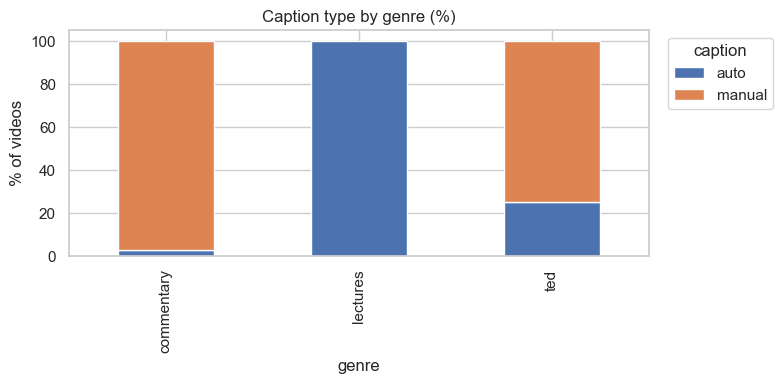

In [4]:
caption_pct = (
    df.groupby("genre")["caption_type"]
      .value_counts(normalize=True)
      .unstack(fill_value=0) * 100
)
ax = caption_pct.plot(kind="bar", stacked=True, figsize=(8, 4))
ax.set_title("Caption type by genre (%)")
ax.set_ylabel("% of videos")
ax.legend(title="caption", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

**Why this matters for limitations.** If one genre is dominated by `auto` captions and another by `manual`, downstream filler/repetition differences can be ASR artifacts rather than genuine genre effects. We will return to this in the limitations section of the report (Step 14).

## 3. Length analysis — H1

H1 predicts longer videos have more removable content. Before testing this, we need to know:
1. How length is distributed per genre.
2. Whether genres are systematically different in length (a confound for H1 vs H3).

Title and channel are kept on the frame so we can sanity-check outliers ("is this 3-hour video actually a podcast supercut?").

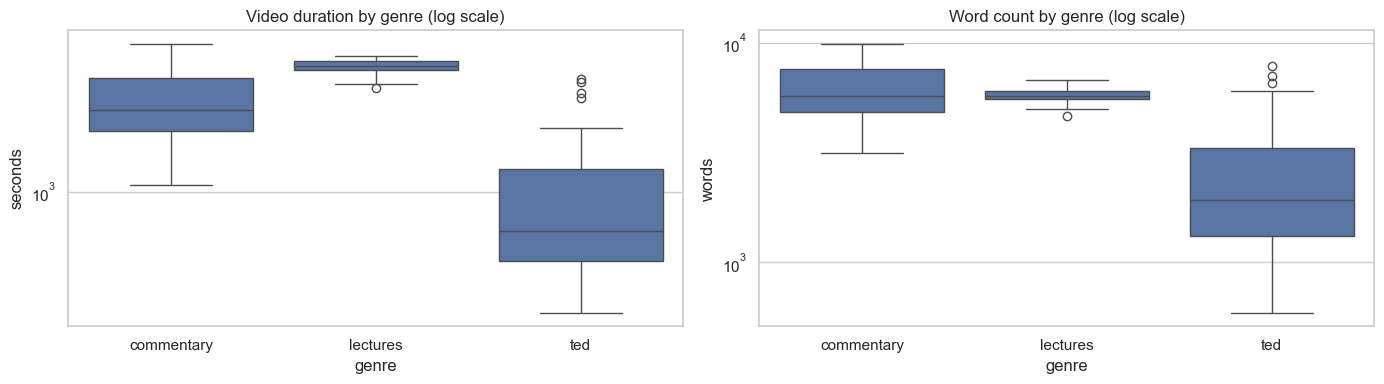


Duration (seconds) by genre:
            count         mean     50%         std
genre                                             
commentary   34.0  2138.117647  2001.0  671.388826
lectures     25.0  2893.600000  2931.0  191.245697
ted          20.0  1067.650000   716.5  766.231879


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=df, x="genre", y="duration_sec", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Video duration by genre (log scale)")
axes[0].set_ylabel("seconds")

sns.boxplot(data=df, x="genre", y="word_count", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Word count by genre (log scale)")
axes[1].set_ylabel("words")

plt.tight_layout()
plt.show()

print("\nDuration (seconds) by genre:")
print(df.groupby("genre")["duration_sec"].describe()[["count", "mean", "50%", "std"]])

Speech rate (words/second) by genre:
                mean       50%       std
genre                                   
commentary  2.882718  2.885587  0.135808
lectures    1.974274  1.950087  0.076752
ted         2.547213  2.507995  0.507501


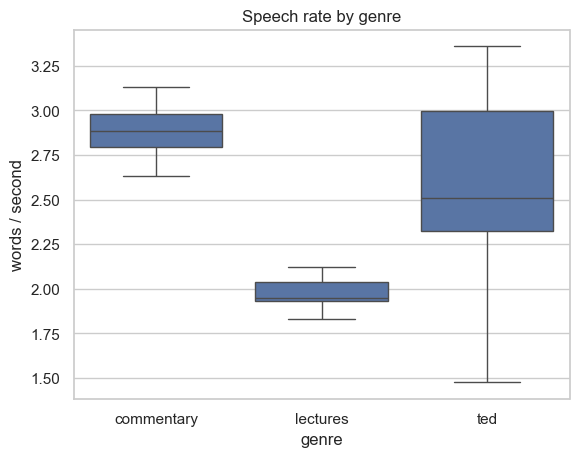

In [6]:
df["speech_rate_wps"] = df["word_count"] / df["duration_sec"]

print("Speech rate (words/second) by genre:")
print(df.groupby("genre")["speech_rate_wps"].describe()[["mean", "50%", "std"]])

ax = sns.boxplot(data=df, x="genre", y="speech_rate_wps")
ax.set_title("Speech rate by genre")
ax.set_ylabel("words / second")
plt.show()

**H4 angle.** Speech rate is a transcript-only proxy for how much off-transcript content (silence, whiteboard work, slide reading) a video has. A lecture at 1.5 wps is doing visual work that the transcript model cannot see; a podcast at 2.8 wps is mostly verbal. Worth flagging in the H4 discussion.

## 4. Lexical features — H3 setup

Per-genre features that double as inputs to the weak labeling functions in Step 9.

In [7]:
FILLERS = {
    "um", "uh", "uhh", "ah", "er", "hmm",
    "like", "basically", "literally", "actually",
    "so", "okay", "right",
}
MULTIWORD_FILLERS = ["you know", "i mean", "sort of", "kind of", "or whatever"]


def transcript_text(transcript: list) -> str:
    return " ".join(e["text"] for e in transcript).lower()


def tokenize(transcript: list) -> list:
    return transcript_text(transcript).split()


def filler_density(transcript: list) -> float:
    """Unigram + multi-word filler tokens / total tokens."""
    text = transcript_text(transcript)
    words = text.split()
    if not words:
        return 0.0
    unigram_hits = sum(1 for w in words if w in FILLERS)
    multi_hits = sum(text.count(p) * len(p.split()) for p in MULTIWORD_FILLERS)
    return (unigram_hits + multi_hits) / len(words)


def ttr(transcript: list) -> float:
    """Type-token ratio — lexical diversity proxy."""
    words = tokenize(transcript)
    return len(set(words)) / len(words) if words else 0.0


df["filler_density"] = df["transcript"].apply(filler_density)
df["ttr"] = df["transcript"].apply(ttr)

print("Filler density by genre:")
print(df.groupby("genre")["filler_density"].describe()[["mean", "50%", "std"]])
print("\nType-token ratio by genre:")
print(df.groupby("genre")["ttr"].describe()[["mean", "50%", "std"]])

Filler density by genre:
                mean       50%       std
genre                                   
commentary  0.021555  0.021484  0.005179
lectures    0.040910  0.043314  0.011317
ted         0.021664  0.019104  0.012178

Type-token ratio by genre:
                mean       50%       std
genre                                   
commentary  0.289465  0.282964  0.037715
lectures    0.133867  0.126363  0.022252
ted         0.366085  0.351578  0.104976


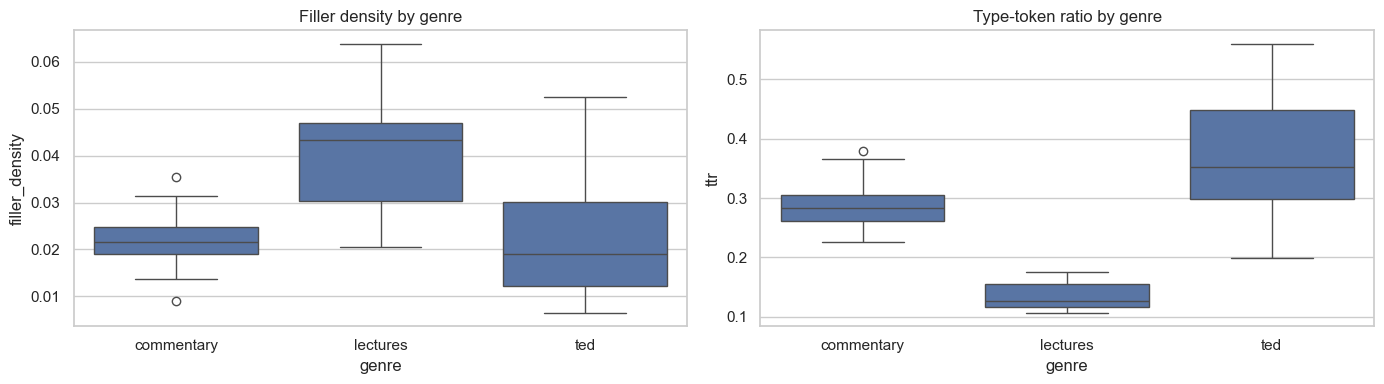

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df, x="genre", y="filler_density", ax=axes[0])
axes[0].set_title("Filler density by genre")
sns.boxplot(data=df, x="genre", y="ttr", ax=axes[1])
axes[1].set_title("Type-token ratio by genre")
plt.tight_layout()
plt.show()

## 5. Repetition proxies — H2 / H4 setup

Trigram repetition is a cheap surface-level redundancy proxy. **Caveat for the report:** trigram repetition does not distinguish *useful* repetition (pedagogical recap, summary) from *redundant* repetition (filler). That distinction is the model's job, not the proxy's. We use it here only to characterize the corpus.

Trigram repetition by genre:
                mean       50%       std
genre                                   
commentary  0.073467  0.070899  0.025736
lectures    0.185517  0.183444  0.025705
ted         0.076168  0.074804  0.036613


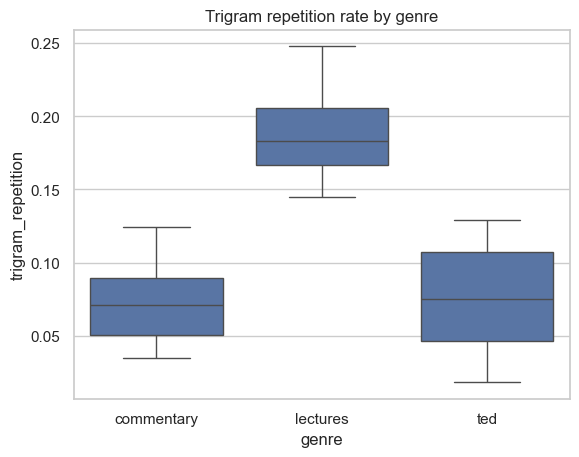

In [9]:
def trigram_repetition(transcript: list, n: int = 3) -> float:
    """Fraction of n-grams that occur more than once in the document."""
    words = tokenize(transcript)
    if len(words) < n:
        return 0.0
    ngrams = [tuple(words[i:i + n]) for i in range(len(words) - n + 1)]
    counts = Counter(ngrams)
    return sum(c for c in counts.values() if c > 1) / len(ngrams)


df["trigram_repetition"] = df["transcript"].apply(trigram_repetition)

print("Trigram repetition by genre:")
print(df.groupby("genre")["trigram_repetition"].describe()[["mean", "50%", "std"]])

ax = sns.boxplot(data=df, x="genre", y="trigram_repetition")
ax.set_title("Trigram repetition rate by genre")
plt.show()

## 6. Visual / pedagogical reference markers — H4 setup

Phrases like *"as you can see,"* *"on this slide,"* or *"look at this graph"* signal content whose meaning lives off-transcript. If a genre is heavy in these markers, a transcript-only model is structurally limited there — evidence for H4.

Visual reference markers per 1000 words:
                mean       50%       std
genre                                   
commentary  0.597265  0.507747  0.463348
lectures    1.334810  1.300954  0.756422
ted         0.419149  0.142248  0.525839

Pedagogical markers per 1000 words:
                mean       50%       std
genre                                   
commentary  0.375088  0.344008  0.306540
lectures    0.484711  0.473186  0.299774
ted         0.301273  0.063857  0.421414


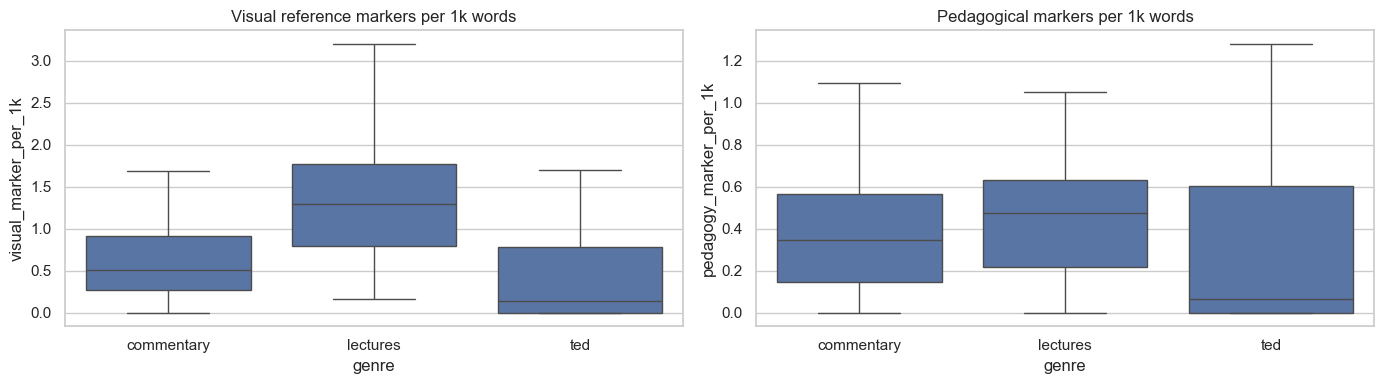

In [10]:
VISUAL_MARKERS = [
    "as you can see", "as you see", "look at", "on this slide",
    "on the screen", "this graph", "this chart", "this diagram",
    "this picture", "this image", "over here", "right here",
    "on the board", "on the left", "on the right",
]
PEDAGOGICAL_MARKERS = [
    "in other words", "to summarize", "to recap", "let me explain",
    "the key point", "the main idea", "for example", "for instance",
    "in conclusion", "the takeaway",
]


def marker_density(transcript: list, markers: list) -> float:
    text = transcript_text(transcript)
    n_words = len(text.split())
    if n_words == 0:
        return 0.0
    hits = sum(text.count(m) for m in markers)
    return hits / (n_words / 1000)  # hits per 1000 words


df["visual_marker_per_1k"] = df["transcript"].apply(lambda t: marker_density(t, VISUAL_MARKERS))
df["pedagogy_marker_per_1k"] = df["transcript"].apply(lambda t: marker_density(t, PEDAGOGICAL_MARKERS))

print("Visual reference markers per 1000 words:")
print(df.groupby("genre")["visual_marker_per_1k"].describe()[["mean", "50%", "std"]])
print("\nPedagogical markers per 1000 words:")
print(df.groupby("genre")["pedagogy_marker_per_1k"].describe()[["mean", "50%", "std"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df, x="genre", y="visual_marker_per_1k", ax=axes[0])
axes[0].set_title("Visual reference markers per 1k words")
sns.boxplot(data=df, x="genre", y="pedagogy_marker_per_1k", ax=axes[1])
axes[1].set_title("Pedagogical markers per 1k words")
plt.tight_layout()
plt.show()

## 7. Length × redundancy — H1 in raw form

We can't measure removability without the model, but **trigram repetition** and **filler density** are defensible redundancy proxies. If H1 has any chance of being true, we should already see a positive duration-vs-redundancy correlation here. A negative or null correlation is informative — it would weaken the prior on H1.

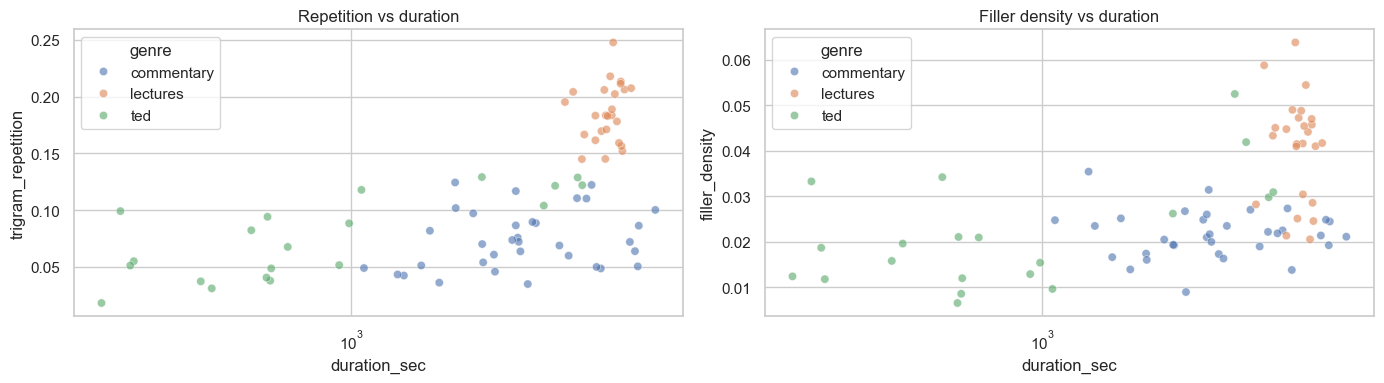


Spearman ρ(duration, trigram_repetition) per genre:
  commentary                 ρ = +0.224  (n=34)
  lectures                   ρ = +0.251  (n=25)
  ted                        ρ = +0.725  (n=20)

Spearman ρ(duration, filler_density) per genre:
  commentary                 ρ = +0.035  (n=34)
  lectures                   ρ = -0.173  (n=25)
  ted                        ρ = +0.332  (n=20)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.scatterplot(
    data=df, x="duration_sec", y="trigram_repetition",
    hue="genre", alpha=0.6, ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_title("Repetition vs duration")

sns.scatterplot(
    data=df, x="duration_sec", y="filler_density",
    hue="genre", alpha=0.6, ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_title("Filler density vs duration")

plt.tight_layout()
plt.show()

print("\nSpearman ρ(duration, trigram_repetition) per genre:")
for g, sub in df.groupby("genre"):
    if len(sub) > 5:
        rho = sub[["duration_sec", "trigram_repetition"]].corr(method="spearman").iloc[0, 1]
        print(f"  {g:25s}  ρ = {rho:+.3f}  (n={len(sub)})")

print("\nSpearman ρ(duration, filler_density) per genre:")
for g, sub in df.groupby("genre"):
    if len(sub) > 5:
        rho = sub[["duration_sec", "filler_density"]].corr(method="spearman").iloc[0, 1]
        print(f"  {g:25s}  ρ = {rho:+.3f}  (n={len(sub)})")

## 8. Feature correlations

Quick sanity check: are these proxies measuring the same thing or capturing different facets? Strongly correlated features mean we can drop one when picking labeling functions; weakly correlated features mean each is contributing independent signal.

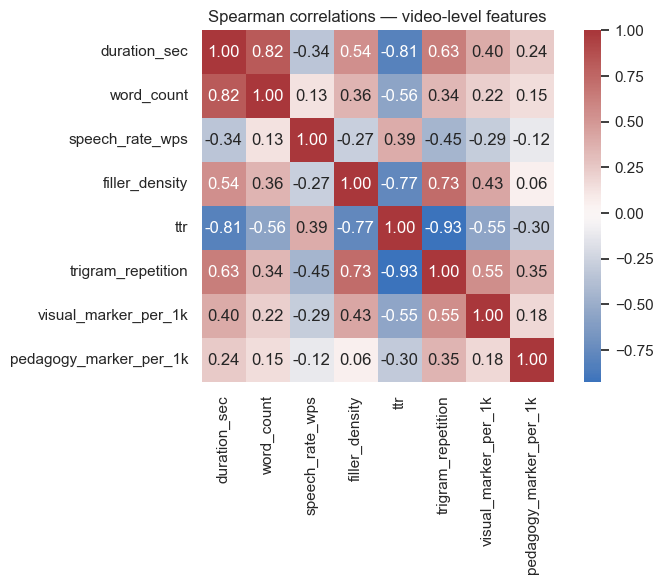

In [12]:
feature_cols = [
    "duration_sec", "word_count", "speech_rate_wps",
    "filler_density", "ttr", "trigram_repetition",
    "visual_marker_per_1k", "pedagogy_marker_per_1k",
]
corr = df[feature_cols].corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Spearman correlations — video-level features")
plt.tight_layout()
plt.show()

## 9. Save summary frame

Drop the heavy `transcript` column before saving — segment-level data lives in `data/processed/segments_*.jsonl` (created by `src/segment.py` later). The summary frame is what later hypothesis tests load.

In [13]:
summary = df.drop(columns=["transcript"])
out = PROCESSED_DIR / "corpus_summary.csv"
summary.to_csv(out, index=False)
print(f"Saved {len(summary):,} rows × {len(summary.columns)} columns to {out}")
summary.head()

Saved 79 rows × 15 columns to ..\data\processed\corpus_summary.csv


,video_id,genre,channel,title,duration_sec,length_bucket,caption_type,word_count,n_segments,speech_rate_wps,filler_density,ttr,trigram_repetition,visual_marker_per_1k,pedagogy_marker_per_1k
0,-QTkPfq7w1A,commentary,Veritasium,This mechanism shrinks when pulled,1387.0,long,auto,4261,622,3.072098,0.025111,0.282093,0.081709,1.173433,0.234687
1,6HVYHNTDOFs,commentary,Veritasium,This Common Substance Was Once Worth Millions,1817.0,long,manual,5283,764,2.907540,0.008896,0.342419,0.045635,0.567859,0.189286
2,9M_QK4stCJU,commentary,Veritasium,Do you know when you're wrong?,1442.0,long,manual,4036,594,2.798890,0.013875,0.379832,0.035944,0.495540,0.991080
3,9szhjhO9epA,commentary,Veritasium,Making A Giant Zipper To Explain How They Work,1245.0,long,manual,3626,509,2.912450,0.023442,0.341975,0.042219,0.275786,0.000000
4,_cr46G2K5Fo,commentary,Veritasium,The Most Controversial Idea In Math,1981.0,long,manual,5255,703,2.652701,0.020932,0.250999,0.116695,0.190295,0.570885


## 10. Things to revisit on the full corpus

When this notebook runs on the full 5000 documents, look out for:

- **Genre confound on length.** If lectures are systematically longer than TED talks, H1 (length effect) and H3 (genre effect) become entangled. Mitigation: stratify reporting by length bucket within each genre.
- **Caption-type confound.** If one genre is mostly auto-captioned, its filler density and trigram repetition can be inflated by ASR artifacts, not real verbal redundancy. Note in limitations and consider running the model separately on the manual-only subset as a robustness check.
- **Speech-rate outliers.** Videos under ~1.5 wps or over ~4 wps often indicate broken captions or unusual content (timelapses, supercuts). Spot-check 5 from each tail and decide whether to drop.
- **Marker densities.** If lectures dominate the visual-marker count by a wide margin, lectures are the genre where H4 (transcript-only model struggles) should bite hardest — this is the cell to cite when discussing H4 in the report.
- **Reproducibility.** The summary frame contains `video_id` and `title` so any later finding can be traced back to source.